# Zipf's Law Analysis Across Multiple Corpora

This notebook analyzes word frequency distributions (Zipf's Law) across several corpora. It includes a short description of each corpus, the processing steps used to clean and tokenize the text, and a report of results with tables and plots suitable for export to PDF.

## Corpora Chosen

Below are the corpora analyzed, with source, author, language, and links to the exact text used:

- A Tale of Two Cities — Charles Dickens (English)
  - Source: Project Gutenberg (ebook page): https://www.gutenberg.org/ebooks/98
  - Text used (UTF-8): https://www.gutenberg.org/files/98/98-0.txt
  - Public domain in the United States.

- The Adventures of Sherlock Holmes — Arthur Conan Doyle (English)
  - Source: Project Gutenberg (ebook page): https://www.gutenberg.org/ebooks/1661
  - Text used (UTF-8): https://www.gutenberg.org/files/1661/1661-0.txt
  - Public domain in the United States.

- El libro de las tierras vírgenes — Rudyard Kipling (Spanish; translation of The Jungle Book)
  - Source: Project Gutenberg (ebook page): https://www.gutenberg.org/ebooks/69552
  - Text used (UTF-8): https://www.gutenberg.org/files/69552/69552-0.txt
  - Public domain status per Gutenberg page; translation author not explicitly recorded here.

- Bachelor Thesis — Nicolae Mogage (Romanian; local PDF)
  - Local file: Dezvoltarea_unui_sistem_de_recunoaștere_a_scrisului_de_mână_pe_foaie_folosind_rețele_neuronale_recurente.pdf
  - Language: Romanian

## Environment Setup
If any imports fail, install the needed packages by running the cell below.

In [ ]:
!pip install requests PyPDF2 matplotlib numpy pandas

In [2]:
%matplotlib inline
import os
import re
import requests
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PyPDF2

## Configuration
We define the list of corpora with source, language, and author (where known). URLs are fetched directly; the PDF is read locally from this folder.

In [3]:
CORPORA = [
    {
        'url': 'https://www.gutenberg.org/files/98/98-0.txt',
        'source': 'A Tale of Two Cities',
        'author': 'Charles Dickens',
        'language': 'English',
        'type': 'url'
    },
    {
        'url': 'https://www.gutenberg.org/files/1661/1661-0.txt',
        'source': 'Sherlock Holmes',
        'author': 'Arthur Conan Doyle',
        'language': 'English',
        'type': 'url'
    },
    {
        'url': 'https://www.gutenberg.org/files/69552/69552-0.txt',
        'source': 'El libro de las tierras vírgenes',
        'author': 'Rudyard Kipling',
        'language': 'Spanish',
        'type': 'url'
    },
    {
        'path': 'Dezvoltarea_unui_sistem_de_recunoaștere_a_scrisului_de_mână_pe_foaie_folosind_rețele_neuronale_recurente.pdf',
        'source': 'Bachelor Thesis',
        'author': 'Nicolae Mogage',
        'language': 'Romanian',
        'type': 'pdf'
    },
]

## Data Processing and Methodology

This section documents how raw texts are acquired and transformed into tokens for analysis.

1) Acquisition
- URLs (Gutenberg): downloaded via HTTP (requests), decoded as UTF-8.
- PDF (local): read with PyPDF2 page-by-page; text extracted using page.extract_text().

2) Normalization
- Lowercasing of all text prior to tokenization.
- No lemmatization/stemming; no stopword removal to preserve raw distributional properties.
- Numbers and punctuation are excluded from tokens.

3) Tokenization (language-aware regex)
- English: [a-zA-Z]+
- Romanian: [a-zA-ZăâîșțĂÂÎȘȚ]+
- Spanish/other Romance: [a-zA-Zà-üñáéíóúü]+

4) Scope
- Entire corpora are used (no limit on number of tokens); this avoids sampling bias.

5) Statistics computed per corpus
- Tokens: total number of word tokens.
- Types: total number of distinct word forms.
- Top 7 Words: the seven most frequent words, shown as word (count).
- Top7%: percentage of all tokens covered by the seven most frequent words.
- Hapax Count: number of word types that occur exactly once (hapax legomena).
- Hapax(Types%): hapax as a percentage of all types.
- Hapax(Tokens%): hapax as a percentage of all tokens (usually small).

6) Zipf plots
- For each corpus and a combined view, we plot rank (1..200) vs frequency to show the characteristic Zipfian decay.

In [4]:
def get_and_process_text(url, language='English'):
    """Downloads, cleans, and tokenizes text from a URL."""
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        response.encoding = 'utf-8'
        full_text = response.text
        print(f'  Downloaded {len(full_text)} characters from URL')
    except Exception as e:
        print(f'  Error downloading text: {e}')
        return []

    if language == 'English':
        tokens = re.findall(r'[a-zA-Z]+', full_text.lower())
    elif language == 'Romanian':
        tokens = re.findall(r'[a-zA-ZăâîșțĂÂÎȘȚ]+', full_text.lower())
    else:
        tokens = re.findall(r'[a-zA-Zà-üñáéíóúü]+', full_text.lower())

    print(f'  Found {len(tokens)} tokens')
    return tokens


def get_and_process_pdf(pdf_path, language='English'):
    """Extracts, cleans, and tokenizes text from a PDF file."""
    if not os.path.isabs(pdf_path):
        pdf_path = os.path.abspath(pdf_path)
    if not os.path.exists(pdf_path):
        print(f'  PDF not found at: {pdf_path}')
        return [], {}

    try:
        with open(pdf_path, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            full_text = ''
            for page in reader.pages:
                page_text = page.extract_text() or ''
                full_text += page_text
            meta = reader.metadata or {}
            print(f'  Extracted {len(full_text)} characters from {len(reader.pages)} pages')
    except Exception as e:
        print(f'  Error reading PDF: {e}')
        return [], {}

    if language == 'English':
        tokens = re.findall(r'[a-zA-Z]+', full_text.lower())
    elif language == 'Romanian':
        tokens = re.findall(r'[a-zA-ZăâîșțĂÂÎȘȚ]+', full_text.lower())
    else:
        tokens = re.findall(r'[a-zA-Zà-üñáéíóúü]+', full_text.lower())
    
    print(f'  Found {len(tokens)} tokens')
    return tokens, meta


def analyze_corpus(tokens):
    if not tokens:
        return {}
    num_tokens = len(tokens)
    word_counts = Counter(tokens)
    num_types = len(word_counts)

    # Top 7 words with counts
    top_7_pairs = word_counts.most_common(7)
    top_7_token_count = sum(c for _, c in top_7_pairs)
    top_7_with_counts = ', '.join([f"{w} ({c})" for w, c in top_7_pairs])

    # Hapax legomena (appear exactly once)
    hapax_legomena = [w for w, c in word_counts.items() if c == 1]
    hapax_types_count = len(hapax_legomena)

    percent_coverage_top_7 = (top_7_token_count / num_tokens) * 100
    percent_hapax_as_types = (hapax_types_count / num_types) * 100
    percent_hapax_as_tokens = (hapax_types_count / num_tokens) * 100
    frequencies = sorted(word_counts.values(), reverse=True)
    return {
        'num_tokens': num_tokens,
        'num_types': num_types,
        'top_7_pairs': top_7_pairs,
        'top_7_with_counts': top_7_with_counts,
        'percent_coverage_top_7': percent_coverage_top_7,
        'percent_hapax_as_types': percent_hapax_as_types,
        'percent_hapax_as_tokens': percent_hapax_as_tokens,
        'hapax_types_count': hapax_types_count,  # new raw count
        'frequencies': frequencies,
    }


def plot_zipf(frequencies, source_name):
    top_200 = frequencies[:200]
    ranks = np.arange(1, len(top_200) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(ranks, top_200, 'b-', linewidth=2)
    plt.title(f"Zipf's Law: Rank vs Frequency (Top 200)\n{source_name}")
    plt.xlabel('Rank')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_comparison(all_results):
    plt.figure(figsize=(10, 6))
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
    linestyles = ['-', '--', '-.', ':', '-', '--']

    for idx, res in enumerate(all_results):
        freqs = res['frequencies'][:200]
        ranks = np.arange(1, len(freqs) + 1)
        color = colors[idx % len(colors)]
        linestyle = linestyles[idx % len(linestyles)]
        label = f"{res['source']} ({res['language']})"
        plt.plot(ranks, freqs, linestyle=linestyle, linewidth=2, color=color, alpha=0.9, label=label)

    plt.title("Zipf's Law Comparison - Top 200 Words")
    plt.xlabel('Rank')
    plt.ylabel('Frequency')
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Run Analysis
This cell processes each corpus, computes descriptive statistics, and aggregates results into a table. For the PDF, the author is read from metadata if available.

In [5]:
all_results = []
rows = []

for cfg in CORPORA:
    print('='*80)
    print(f"Processing: {cfg['source']} ({cfg['language']})")
    print('='*80)

    if cfg['type'] == 'pdf':
        tokens, meta = get_and_process_pdf(cfg['path'], cfg['language'])
        author = cfg.get('author')
        if not author:
            author = getattr(meta, 'author', None) if hasattr(meta, 'author') else meta.get('/Author') if isinstance(meta, dict) else None
    else:
        tokens = get_and_process_text(cfg['url'], cfg['language'])
        author = cfg.get('author')

    if not tokens:
        print(f"  Skipping {cfg['source']} due to empty token list.")
        continue

    analysis = analyze_corpus(tokens)
    analysis['source'] = cfg['source']
    analysis['language'] = cfg['language']
    analysis['author'] = author or 'Unknown'
    all_results.append(analysis)

    print("Most Freq. 7 (word: count):", analysis['top_7_with_counts'])

    rows.append({
        'Source': cfg['source'],
        'Author': author or 'Unknown',
        'Language': cfg['language'],
        'Tokens': analysis['num_tokens'],
        'Types': analysis['num_types'],
        'Top7%': round(analysis['percent_coverage_top_7'], 2),
        'Hapax Count': analysis['hapax_types_count'],
        'Hapax(Types%)': round(analysis['percent_hapax_as_types'], 2),
        'Hapax(Tokens%)': round(analysis['percent_hapax_as_tokens'], 2),
        'Top 7 Words': analysis['top_7_with_counts'],
    })

df_results = pd.DataFrame(rows)
df_results

Processing: A Tale of Two Cities (English)
  Downloaded 793331 characters from URL
  Found 141633 tokens
Most Freq. 7 (word: count): the (8242), and (5067), of (4142), to (3653), a (3016), in (2664), it (2082)
Processing: Sherlock Holmes (English)
  Downloaded 593731 characters from URL
  Found 108924 tokens
Most Freq. 7 (word: count): the (5822), and (3085), i (3038), to (2826), of (2781), a (2701), in (1826)
Processing: El libro de las tierras vírgenes (Spanish)
  Downloaded 817320 characters from URL
  Found 138862 tokens
Most Freq. 7 (word: count): de (7272), que (5144), y (4686), la (4674), el (3740), á (3654), en (2905)
Processing: Bachelor Thesis (Romanian)
  Extracted 104906 characters from 52 pages
  Found 16826 tokens
Most Freq. 7 (word: count): a (1352), de (668), s (418), i (335), n (306), care (190), o (180)


,Source,Author,Language,Tokens,Types,Top7%,Hapax Count,Hapax(Types%),Hapax(Tokens%),Top 7 Words
0,A Tale of Two Cities,Charles Dickens,English,141633,9941,20.38,4290,43.15,3.03,"the (8242), and (5067), of (4142), to (3653), ..."
1,Sherlock Holmes,Arthur Conan Doyle,English,108924,8067,20.27,3542,43.91,3.25,"the (5822), and (3085), i (3038), to (2826), o..."
2,El libro de las tierras vírgenes,Rudyard Kipling,Spanish,138862,13621,23.10,7033,51.63,5.06,"de (7272), que (5144), y (4686), la (4674), el..."
3,Bachelor Thesis,Nicolae Mogage,Romanian,16826,3520,20.50,1974,56.08,11.73,"a (1352), de (668), s (418), i (335), n (306),..."


## Report of the Results

The table above summarizes the core statistics for each corpus:
- Source, Author, Language: bibliographic context of the corpus.
- Tokens: total tokens in the processed text.
- Types: unique word forms observed.
- Top 7 Words: the seven most frequent words, including counts in parentheses.
- Top7%: proportion of tokens accounted for by the top seven words; higher values indicate a more concentrated frequency head.
- Hapax Count: number of words that appear exactly once.
- Hapax(Types%): hapax as a share of all types; larger values often reflect lexical diversity and tail heaviness.
- Hapax(Tokens%): hapax as a share of all tokens; typically small but informative for tail mass.

Below, individual Zipf plots illustrate rank-frequency curves per corpus, followed by a comparative plot overlaying all corpora. Together, these views support assessing how language and genre differences influence frequency distributions.

## Individual Zipf Plots
The following plots show rank vs frequency (top 200 words) for each corpus.

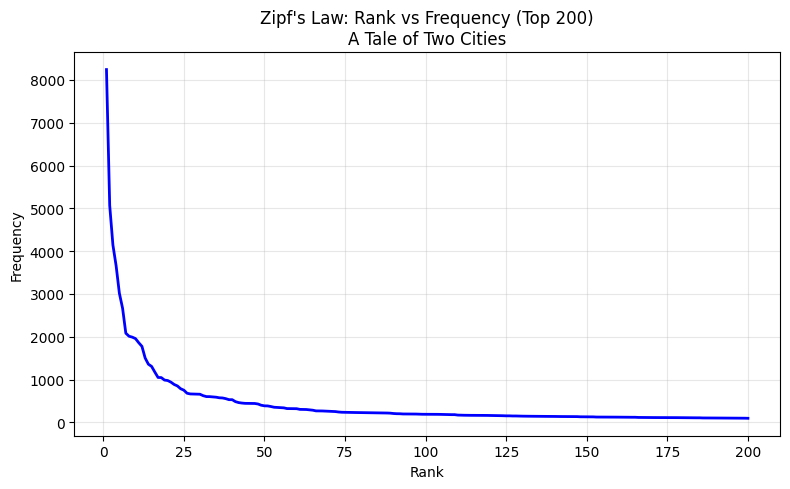

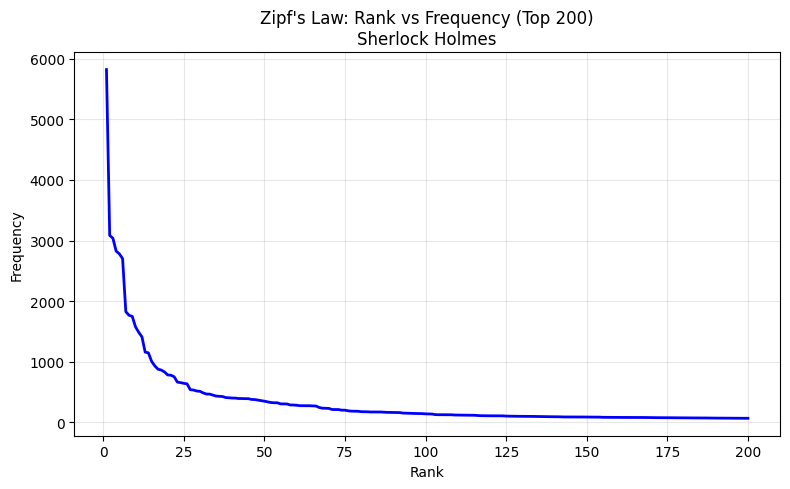

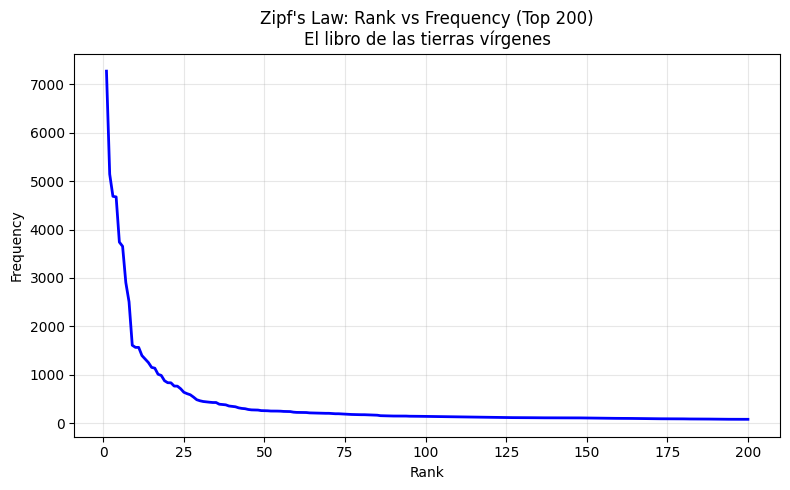

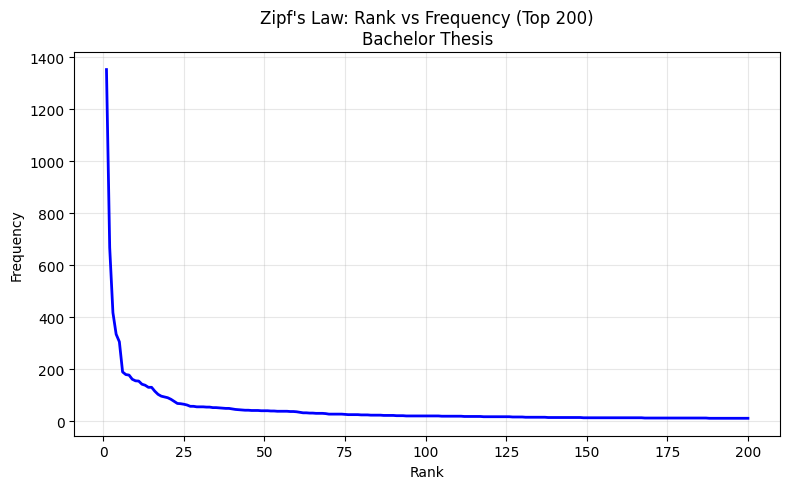

In [6]:
for res in all_results:
    plot_zipf(res['frequencies'], res['source'])

## Comparative Plot
A single figure comparing the top-200 rank-frequency curves across corpora.

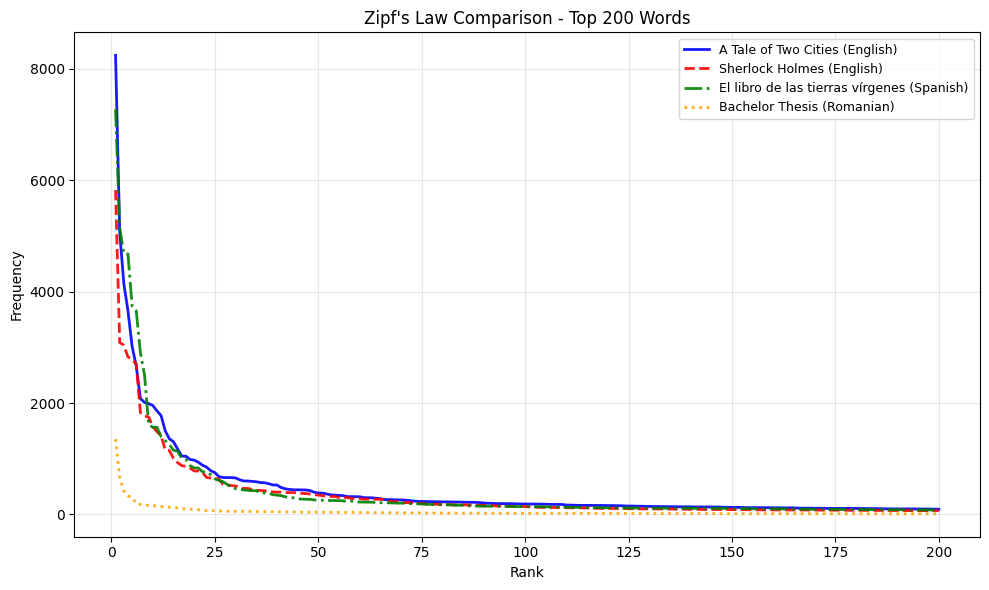

In [7]:
plot_comparison(all_results)

## Methods Summary
- Entire texts are used without limiting to a fixed number of words.
- Lowercasing and alphabetic tokenization (regex) are applied.
- Language-specific regex: English (A–Z), Romanian (ă, â, î, ș, ț), Spanish/Romance (including accents and ñ).
- PDF text is extracted page-by-page using PyPDF2; metadata read where available.
- Reported metrics: tokens, types, top-7 words with counts and coverage, hapax absolute count, and hapax percentages.

## Results Summary
This cell generates a short narrative summary based on the computed statistics.

In [8]:
if not df_results.empty:
    biggest = df_results.loc[df_results['Tokens'].idxmax()]
    smallest = df_results.loc[df_results['Tokens'].idxmin()]
    best_coverage = df_results.loc[df_results['Top7%'].idxmax()]
    hapax_types_low = df_results.loc[df_results['Hapax(Types%)'].idxmin()]
    hapax_types_high = df_results.loc[df_results['Hapax Count'].idxmax()]
    print(
        f"The largest corpus by tokens is {biggest['Source']} ({biggest['Language']}) with {biggest['Tokens']:,} tokens.\n"
        f"The smallest corpus by tokens is {smallest['Source']} ({smallest['Language']}) with {smallest['Tokens']:,} tokens.\n"
        f"The highest top-7 coverage is for {best_coverage['Source']} at {best_coverage['Top7%']}%.\n"
        f"The lowest proportion of hapax (as % of types) is for {hapax_types_low['Source']} at {hapax_types_low['Hapax(Types%)']}%.\n"
        f"The highest absolute hapax count is {hapax_types_high['Hapax Count']:,} in {hapax_types_high['Source']}."
    )
else:
    print('No results to summarize.')

The largest corpus by tokens is A Tale of Two Cities (English) with 141,633 tokens.
The smallest corpus by tokens is Bachelor Thesis (Romanian) with 16,826 tokens.
The highest top-7 coverage is for El libro de las tierras vírgenes at 23.1%.
The lowest proportion of hapax (as % of types) is for A Tale of Two Cities at 43.15%.
The highest absolute hapax count is 7,033 in El libro de las tierras vírgenes.
